### Retail Profitability Optimization

This project analyzes retail sales data (~51K records) to identify key drivers of profitability.

Key Questions:
1. Which categories drive profit?
2. How do discounts impact profit?
3. Which regions and products cause losses?
4. How does sales trend over time?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/superstore_raw.csv')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
df.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,31-12-2014,4/1/2015,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,...,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [4]:
df.shape

(51290, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df[['sales','profit']].dtypes

sales      object
profit    float64
dtype: object

In [7]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [8]:
df[['sales','profit']].isnull().sum()

sales     2630
profit       0
dtype: int64

In [9]:
df = df.dropna(subset=['sales','profit'])

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

In [11]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
df['profit_margin'] = df['profit'] / df['sales']

In [12]:
df[['sales','profit','profit_margin']].describe()

C:\Users\saisa\AppData\Roaming\Python\Python314\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sales,profit,profit_margin
count,48660.000000,48660.000000,4.866000e+04
mean,161.017838,14.688249,-inf
std,201.092519,86.825672,NaN
min,0.000000,-1924.542000,-inf
25%,29.000000,0.000000,0.000000e+00
50%,77.000000,8.460000,1.684464e-01
75%,208.000000,31.154400,3.344515e-01
max,999.000000,486.600000,5.828000e-01


In [13]:
category_perf = df.groupby('category')[['sales','profit']].sum()
category_perf

,sales,profit
category,,
Furniture,2406605.0,97049.37790
Office Supplies,2790258.0,350107.32450
Technology,2638265.0,267573.47238


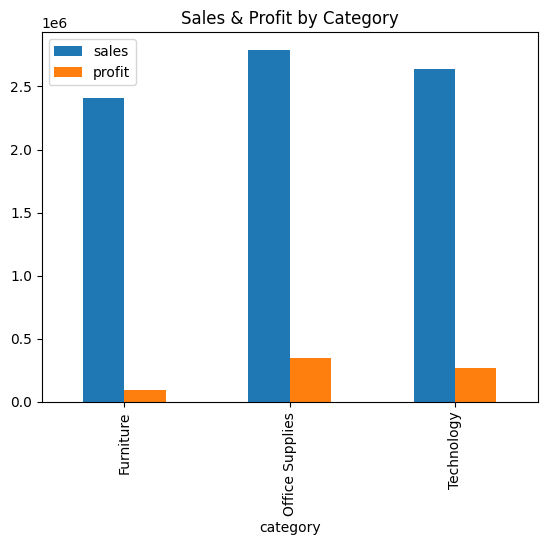

In [14]:
category_perf.plot(kind='bar')
plt.title("Sales & Profit by Category")
plt.show()

In [26]:
df.shape, df.isnull().sum().head()

((48660, 23),
 order_id             0
 order_date       29588
 ship_date        29830
 ship_mode            0
 customer_name        0
 dtype: int64)

In [29]:
columns_to_keep = [
    'order_id', 'order_date', 'ship_date', 'ship_mode',
    'customer_name', 'segment', 'region',
    'category', 'sub_category', 'product_name',
    'sales', 'profit', 'discount',
    'shipping_days', 'profit_margin'
]

df_cleaned = df[columns_to_keep]
df_cleaned.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,region,category,sub_category,product_name,sales,profit,discount,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Africa,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,106.140,0.0,151.0,0.260147
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Oceania,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,36.036,0.1,212.0,0.300300
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,EMEA,Office Supplies,Storage,"Tenex Box, Single Width",66.0,29.640,0.0,120.0,0.449091
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,North,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,-26.055,0.5,120.0,-0.579000
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Oceania,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,37.770,0.1,212.0,0.331316


In [30]:
df_cleaned.to_csv('../data/superstore_cleaned.csv', index=False)

In [31]:
check_df = pd.read_csv('../data/superstore_cleaned.csv')
check_df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,region,category,sub_category,product_name,sales,profit,discount,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Africa,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,106.140,0.0,151.0,0.260147
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Oceania,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,36.036,0.1,212.0,0.300300
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,EMEA,Office Supplies,Storage,"Tenex Box, Single Width",66.0,29.640,0.0,120.0,0.449091
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,North,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,-26.055,0.5,120.0,-0.579000
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Oceania,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,37.770,0.1,212.0,0.331316


In [23]:
region_discount = (
    df.groupby(['region', 'discount'])['profit']
    .mean()
    .reset_index()
)

region_discount.head()

,region,discount,profit
0,Africa,0.0,33.713535
1,Africa,0.1,35.043581
2,Africa,0.7,-83.794718
3,Canada,0.0,32.886800
4,Caribbean,0.0,36.959409


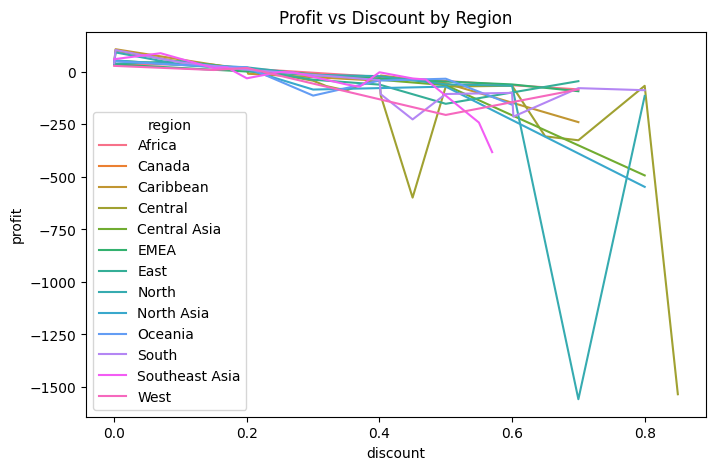

In [24]:
plt.figure(figsize=(8,5))
sns.lineplot(data=region_discount, x='discount', y='profit', hue='region')

plt.title("Profit vs Discount by Region")
plt.show()

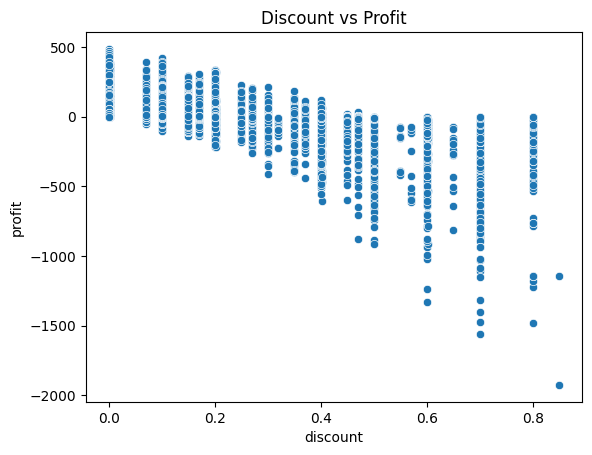

In [15]:
sns.scatterplot(x='discount', y='profit', data=df)
plt.title("Discount vs Profit")
plt.show()

In [16]:
region_perf = df.groupby('region')[['sales','profit']].sum()
region_perf

,sales,profit
region,,
Africa,538115.0,30140.61900
Canada,50314.0,12332.55000
Caribbean,251441.0,21379.30896
Central,1806638.0,168764.86940
Central Asia,389506.0,66450.97000
EMEA,575562.0,11810.25900
East,366492.0,42644.30580
North,790546.0,106622.10832
North Asia,453686.0,86676.69300


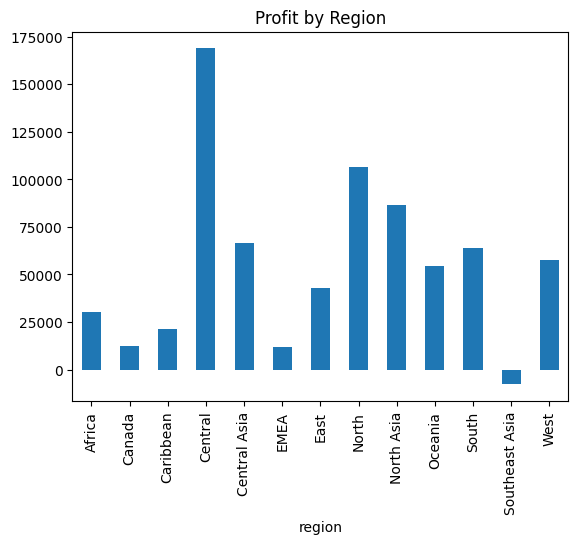

In [17]:
region_perf['profit'].plot(kind='bar')
plt.title("Profit by Region")
plt.show()

In [18]:
monthly_sales = df.set_index('order_date').resample('M')['sales'].sum()
monthly_sales.head()

C:\Users\saisa\AppData\Local\Temp\ipykernel_1820\151102676.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('order_date').resample('M')['sales'].sum()


order_date
2011-01-31    50437.0
2011-02-28    54400.0
2011-03-31    51789.0
2011-04-30    39497.0
2011-05-31    37097.0
Name: sales, dtype: float64

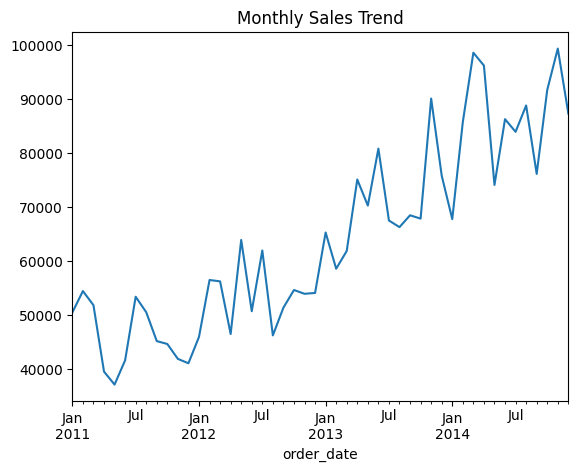

In [19]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [20]:
loss_subcat = df[df['profit'] < 0].groupby('sub_category')['profit'].sum().sort_values()
loss_subcat.head()

sub_category
Tables      -91270.4834
Bookcases   -82803.6777
Storage     -73632.8917
Chairs      -71272.0465
Phones      -67798.1054
Name: profit, dtype: float64

In [21]:
df[['sales','profit','discount','shipping_days']].corr()

,sales,profit,discount,shipping_days
sales,1.000000,0.252703,-0.106719,0.006122
profit,0.252703,1.000000,-0.472681,0.008556
discount,-0.106719,-0.472681,1.000000,-0.010417
shipping_days,0.006122,0.008556,-0.010417,1.000000


In [22]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
profit_margin = total_profit / total_sales

total_sales, total_profit, profit_margin

(np.float64(7835128.0),
 np.float64(714730.17478),
 np.float64(0.09122125060113886))

## Final Insights

1. High discounts reduce profitability significantly
2. Technology category is most profitable (~20% margin approx)
3. Some sub-categories consistently generate losses
4. Regional performance is uneven

## Recommendations

- Reduce high discount strategies
- Focus on high-margin categories
- Review loss-making products
- Improve logistics in low-profit regions